#Lojistik Regresyon

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
X , y = make_classification(
    n_samples=1000,
    n_informative=2,
    n_features=5,
    n_classes=2,
    random_state=42
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lr_model.predict(X_test)
basari = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari)

Başarı skoru :  0.89


#KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn_model.predict(X_test)
basari = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari)

Başarı skoru :  0.9033333333333333


#SVM - SVR

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = svm_model.predict(X_test)
basari = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari)

Başarı skoru :  0.8866666666666667


#YSA

In [ ]:
!pip install -q gdown
import gdown

gdown.download('https://drive.google.com/uc?id=1g1_0Wd-ceudOcksfF0AwWg_ybTnGrkPc', 'memekanseri.data', quiet=False)

In [ ]:
import pandas as pd

In [ ]:
veri = pd.read_csv('memekanseri.data', header=None)

In [ ]:
kolon_isimleri = veri.iloc[0]

In [ ]:
print(kolon_isimleri)
print(veri.head(10))

0    30
1    64
2     1
3     1
Name: 0, dtype: int64
    0   1   2  3
0  30  64   1  1
1  30  62   3  1
2  30  65   0  1
3  31  59   2  1
4  31  65   4  1
5  33  58  10  1
6  33  60   0  1
7  34  59   0  2
8  34  66   9  2
9  34  58  30  1


In [ ]:
veri.columns = ["Yas","Ameliyat_Yili","Bulgular","Canli"]
print(veri.head(10))

   Yas  Ameliyat_Yili  Bulgular  Canli
0   30             64         1      1
1   30             62         3      1
2   30             65         0      1
3   31             59         2      1
4   31             65         4      1
5   33             58        10      1
6   33             60         0      1
7   34             59         0      2
8   34             66         9      2
9   34             58        30      1


In [ ]:
veri.loc[veri['Canli']==2,'Canli']=0
print(veri.head(10))

   Yas  Ameliyat_Yili  Bulgular  Canli
0   30             64         1      1
1   30             62         3      1
2   30             65         0      1
3   31             59         2      1
4   31             65         4      1
5   33             58        10      1
6   33             60         0      1
7   34             59         0      0
8   34             66         9      0
9   34             58        30      1


In [ ]:
veri['Canli'] = veri['Canli'].astype('int64')
print(veri.dtypes)

Yas              int64
Ameliyat_Yili    int64
Bulgular         int64
Canli            int64
dtype: object


In [ ]:
from sklearn.preprocessing import MinMaxScaler

X = veri.drop('Canli',axis=1)
y = veri['Canli']

In [ ]:
ölceklendirme = MinMaxScaler()
X = ölceklendirme.fit_transform(X)
X = pd.DataFrame(X, columns=['Yas','Ameliyat_Yili','Bulgular'])
print(X.head(10))

        Yas  Ameliyat_Yili  Bulgular
0  0.000000       0.545455  0.019231
1  0.000000       0.363636  0.057692
2  0.000000       0.636364  0.000000
3  0.018868       0.090909  0.038462
4  0.018868       0.636364  0.076923
5  0.056604       0.000000  0.192308
6  0.056604       0.181818  0.000000
7  0.075472       0.090909  0.000000
8  0.075472       0.727273  0.173077
9  0.075472       0.000000  0.576923


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense


In [ ]:
print(X_train.shape)

(244, 3)


In [ ]:
ysa_model = Sequential()

In [ ]:
ysa_model.add(Dense(128,input_shape=(X_train.shape[1],),activation='relu'))
ysa_model.add(Dense(64,activation='relu'))
ysa_model.add(Dense(32,activation='relu'))
ysa_model.add(Dense(16,activation='relu'))
ysa_model.add(Dense(1,activation='sigmoid'))
ysa_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ysa_model.fit(X_train, y_train, epochs=10000,verbose=0)

In [ ]:
kayıp, basari = ysa_model.evaluate(X_test, y_test)
print("Kayıp : ",kayıp)
print("Başarı : ",basari)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step - accuracy: 0.6935 - loss: 12.1114
Kayıp :  12.111442565917969
Başarı :  0.6935483813285828


#K-Means Clustering

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [ ]:
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

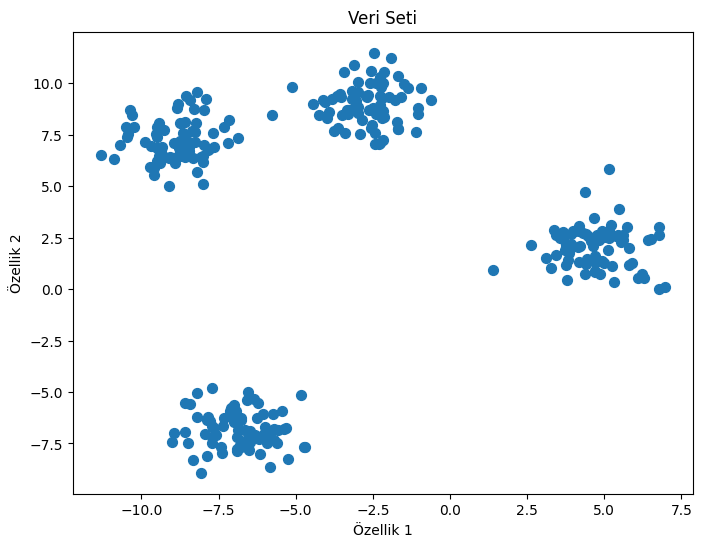

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1],s=50)

plt.title('Veri Seti')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

KMeans(n_clusters=5)

In [ ]:
centers = kmeans.cluster_centers_
labels = kmeans.labels_

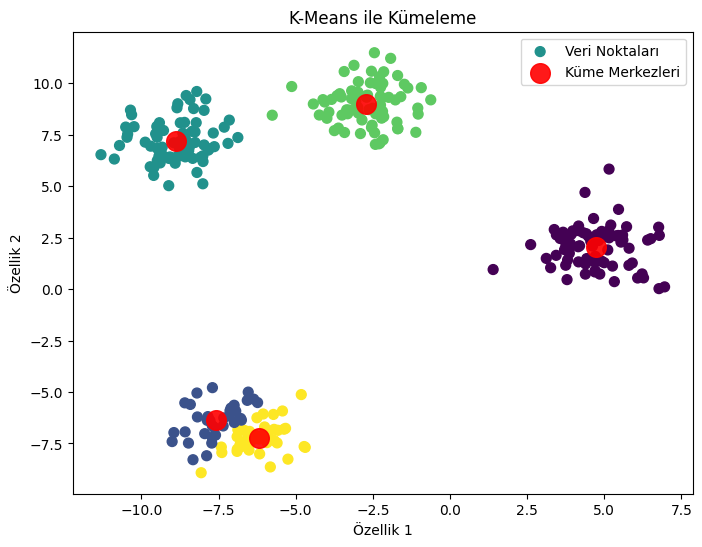

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1],c=labels, s=50, label='Veri Noktaları')
plt.scatter(centers[:,0], centers[:,1],c='red',s=200, alpha=0.9,label='Küme Merkezleri')

plt.title('K-Means ile Kümeleme')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.legend()
plt.show()

#Hiyerarşik Kümeleme

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

In [ ]:
hiyerarsik = linkage(X, 'single')

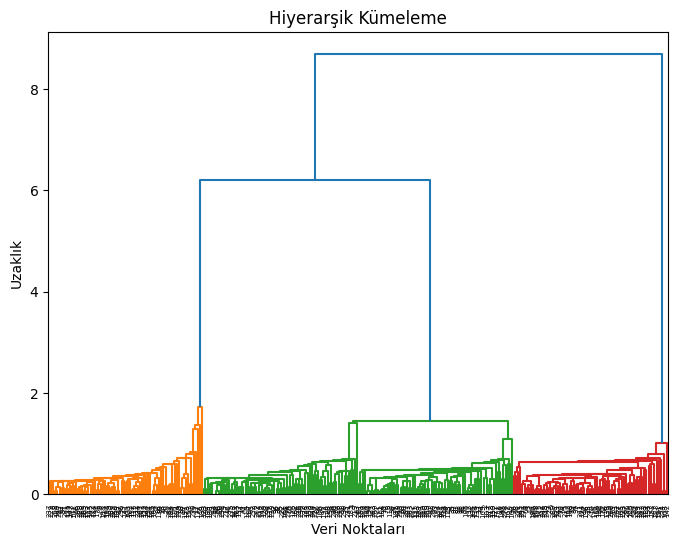

In [ ]:
plt.figure(figsize=(8,6))

dendrogram(
    hiyerarsik,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title('Hiyerarşik Kümeleme')
plt.xlabel('Veri Noktaları')
plt.ylabel('Uzaklık')
plt.show()

In [ ]:
hiyerarsik2 = linkage(X,'complete')

kümeleme = fcluster(
    hiyerarsik2,
    20,
    criterion='distance'
)

In [ ]:
print('Oluşan küme sayısı : ',len(np.unique(kümeleme)))

Oluşan küme sayısı :  2


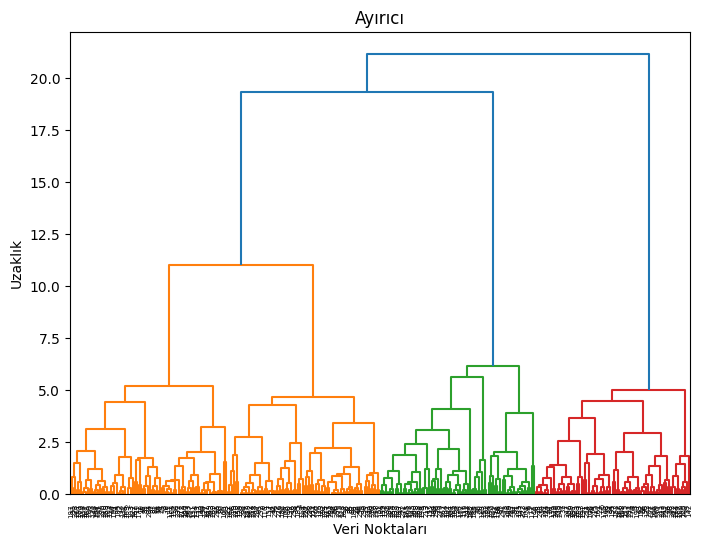

In [ ]:
plt.figure(figsize=(8,6))

dendrogram(
    hiyerarsik2,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title('Ayırıcı')
plt.xlabel('Veri Noktaları')
plt.ylabel('Uzaklık')
plt.show()